# WildTrace Pipeline Driver

This notebook is the current driver for the agentic WildTrace pipeline. It runs the DAG-style stage scripts in order so we can inspect outputs while keeping the same script boundaries that Airflow will use later.

Before running the notebook:
- run `uv sync` from the repo root
- start Ollama with `ollama serve`
- pull the configured local models
- make sure BioCLIP runs on a CUDA-capable GPU machine for bronze enrichment
- create `.env` from `.env.example` if you need custom model or host settings


In [2]:
from collections import Counter
from pathlib import Path
import json
import subprocess

import yaml
from IPython.display import SVG, display
from PIL import Image

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "scripts").exists():
    for parent in REPO_ROOT.parents:
        if (parent / "scripts").exists() and (parent / "configs").exists():
            REPO_ROOT = parent
            break

SCRIPTS_DIR = REPO_ROOT / 'scripts'
CONFIG_DIR = REPO_ROOT / 'configs'
PYTHON = REPO_ROOT / '.venv' / 'bin' / 'python'

if not PYTHON.exists():
    raise FileNotFoundError(f"{PYTHON} not found. Run `uv sync` from {REPO_ROOT} first.")

print("repo_root =", REPO_ROOT)
print("python =", PYTHON)
print("scripts_dir =", SCRIPTS_DIR)
print("config_dir =", CONFIG_DIR)

RUN_FETCH_IDEMPOTENCY_CHECK = False
print('RUN_FETCH_IDEMPOTENCY_CHECK =', RUN_FETCH_IDEMPOTENCY_CHECK)


repo_root = /home/shravan/Workspace/WildTrace
python = /home/shravan/Workspace/WildTrace/.venv/bin/python
scripts_dir = /home/shravan/Workspace/WildTrace/scripts
config_dir = /home/shravan/Workspace/WildTrace/configs
RUN_FETCH_IDEMPOTENCY_CHECK = False


In [3]:
def run_stage(script_name: str):
    script = SCRIPTS_DIR / script_name
    cmd = [str(PYTHON), str(script), '--repo-root', str(REPO_ROOT), '--config-dir', str(CONFIG_DIR)]
    print('Running:', ' '.join(cmd))
    return subprocess.run(cmd, check=True)


def load_ndjson(path: Path):
    if not path.exists():
        return []
    return [json.loads(line) for line in path.read_text(encoding='utf-8').splitlines() if line.strip()]

## Inspect Configs

Tune these first before running a larger fetch.

In [4]:
for name in ['datasets.yaml', 'storage.yaml', 'quality.yaml', 'viewpoints.yaml', 'models.yaml', 'export.yaml']:
    path = CONFIG_DIR / name
    print(f'\n## {name}')
    print(yaml.safe_dump(yaml.safe_load(path.read_text()), sort_keys=False))


## datasets.yaml
task_type: drawing
source_dataset: openimages
categories:
- name: Cat
  limit: 10
- name: Dog
  limit: 10
- name: Horse
  limit: 10
- name: Bird
  limit: 10
- name: Butterfly
  limit: 10
- name: Fish
  limit: 10
fetch:
  source_mode: official
  records_path: null
  records: []
  timeout_seconds: 30
  user_agent: WildTraceETL/0.1
  manifest_path: outputs/bronze/manifests/openimages_fetch.ndjson
  latest_view_path: outputs/bronze/manifests/openimages_fetch_latest.ndjson
  official:
    splits:
    - train
    - validation
    require_masks: true
    class_descriptions_url: https://storage.googleapis.com/openimages/v7/oidv7-class-descriptions-boxable.csv
    image_base_url_template: https://open-images-dataset.s3.amazonaws.com/{split}/{image_id}.jpg
    image_info_urls:
      train: https://storage.googleapis.com/openimages/2018_04/train/train-images-boxable-with-rotation.csv
      validation: https://storage.googleapis.com/openimages/2018_04/validation/validation-images

## Step 1: Fetch Open Images

In [17]:
run_stage('fetch_openimages.py')

fetch_ledger = REPO_ROOT / 'outputs' / 'bronze' / 'manifests' / 'openimages_fetch.ndjson'
fetch_latest = REPO_ROOT / 'outputs' / 'bronze' / 'manifests' / 'openimages_fetch_latest.ndjson'
fetch_rows = load_ndjson(fetch_ledger)
fetch_latest_rows = load_ndjson(fetch_latest)
print('fetch ledger rows =', len(fetch_rows))
print('fetch latest rows =', len(fetch_latest_rows))
fetch_latest_rows[:3]

Running: /home/shra012/Workspace/WildTrace/.venv/bin/python /home/shra012/Workspace/WildTrace/scripts/fetch_openimages.py --repo-root /home/shra012/Workspace/WildTrace --config-dir /home/shra012/Workspace/WildTrace/configs
fetch ledger rows = 839
fetch latest rows = 471


[{'asset_version': 2,
  'category': 'Bird',
  'failure_reason': None,
  'fetch_status': 'success',
  'fetched_at': '2026-04-05T03:07:48.150724+00:00',
  'image_checksum': '0ecd767fef243f95fd5ee198eef4287d868a4593474df88e567b64c62b3cb673',
  'image_path': 'outputs/bronze/images/Bird/052f30216bc7427f/v0002.jpg',
  'image_uri': 'local://outputs/bronze/images/Bird/052f30216bc7427f/v0002.jpg',
  'license': 'https://creativecommons.org/licenses/by/2.0/',
  'mask_archive_url': 'https://storage.googleapis.com/openimages/v5/train-masks/train-masks-6.zip',
  'mask_checksum': 'ed357ba80082398b463fe061ad3697afff307579c9ac1829b8da71ea2aded62e',
  'mask_path': 'outputs/bronze/masks/Bird/052f30216bc7427f/v0002.png',
  'mask_path_in_archive': '60ccd324d6d410f2_m015p6_9634a2c8.png',
  'mask_source_url': None,
  'mask_uri': 'local://outputs/bronze/masks/Bird/052f30216bc7427f/v0002.png',
  'metadata_path': 'outputs/bronze/metadata/Bird/052f30216bc7427f/v0002.json',
  'record_id': 'a740c798fa9ad307',
  's

### Bronze Cache Check

These cells help us verify that bronze fetch is reusing existing downloaded assets instead of downloading the same files again.


In [18]:
fetch_versions = Counter(row['asset_version'] for row in fetch_rows)
latest_versions = Counter(row['asset_version'] for row in fetch_latest_rows)
duplicate_latest_image_paths = [path for path, count in Counter(row['image_path'] for row in fetch_latest_rows).items() if count > 1]
duplicate_latest_mask_paths = [path for path, count in Counter(row['mask_path'] for row in fetch_latest_rows if row.get('mask_path')).items() if count > 1]

print('fetch ledger rows =', len(fetch_rows))
print('latest success rows =', len(fetch_latest_rows))
print('asset version distribution =', dict(fetch_versions))
print('latest version distribution =', dict(latest_versions))
print('duplicate latest image paths =', len(duplicate_latest_image_paths))
print('duplicate latest mask paths =', len(duplicate_latest_mask_paths))
print('reused existing bronze assets =', len(fetch_rows) == len(fetch_latest_rows) and max(fetch_versions or {0: 0}) == 1)

if duplicate_latest_image_paths:
    duplicate_latest_image_paths[:10]


fetch ledger rows = 839
latest success rows = 471
asset version distribution = {1: 529, 2: 310}
latest version distribution = {2: 310, 1: 161}
duplicate latest image paths = 0
duplicate latest mask paths = 0
reused existing bronze assets = False


In [19]:
if RUN_FETCH_IDEMPOTENCY_CHECK:
    fetch_rows_before = load_ndjson(fetch_ledger)
    run_stage('fetch_openimages.py')
    fetch_rows_after = load_ndjson(fetch_ledger)
    new_rows = len(fetch_rows_after) - len(fetch_rows_before)
    print('new fetch ledger rows after rerun =', new_rows)
    if new_rows == 0:
        print('No new downloads were needed. Bronze fetch reused existing assets.')
    else:
        print('Fetch added new ledger rows; inspect version bumps or source changes.')
else:
    print('Idempotency rerun skipped. Set RUN_FETCH_IDEMPOTENCY_CHECK = True to rerun fetch and verify no extra downloads.')


Idempotency rerun skipped. Set RUN_FETCH_IDEMPOTENCY_CHECK = True to rerun fetch and verify no extra downloads.


## Step 2: Curate Bronze

In [20]:
run_stage('curate_bronze.py')

bronze_curated = REPO_ROOT / 'outputs' / 'bronze' / 'manifests' / 'bronze_curated.ndjson'
bronze_accepted = REPO_ROOT / 'outputs' / 'bronze' / 'manifests' / 'bronze_accepted.ndjson'
curated_rows = load_ndjson(bronze_curated)
accepted_rows = load_ndjson(bronze_accepted)
print('bronze curated rows =', len(curated_rows))
print('bronze accepted rows =', len(accepted_rows))
accepted_rows[:3]

Running: /home/shra012/Workspace/WildTrace/.venv/bin/python /home/shra012/Workspace/WildTrace/scripts/curate_bronze.py --repo-root /home/shra012/Workspace/WildTrace --config-dir /home/shra012/Workspace/WildTrace/configs
bronze curated rows = 471
bronze accepted rows = 161


[{'angle_bucket': 'left_profile',
  'angle_feasible': True,
  'category': 'Cat',
  'curation_flags': [],
  'curation_status': 'accepted',
  'deleted_paths': [],
  'image_checksum': '241018ce4f3e2d2bb59d341d74954545a549fd908fc3cb44a39cabc37e365d00',
  'image_path': 'outputs/bronze/images/Cat/01a6f4902a05f148/v0001.jpg',
  'image_uri': 'local://outputs/bronze/images/Cat/01a6f4902a05f148/v0001.jpg',
  'label_confidence': 0.7223939299583435,
  'label_source': 'imageomics/bioclip',
  'lineage': {'bronze_config_hash': '0b23aff67844081b',
   'curated_at': '2026-04-04T21:25:39.284948+00:00',
   'enrichment_model': {'cache_dir': '/home/shra012/.cache/huggingface',
    'candidate_labels': ['cat', 'domestic cat'],
    'device': 'cuda',
    'model_backend': 'huggingface',
    'model_id': 'imageomics/bioclip',
    'model_name': 'imageomics/bioclip'},
   'fetch_record_id': '5fad37a8d9d8b4fd'},
  'mask_path': 'outputs/bronze/masks/Cat/01a6f4902a05f148/v0001.png',
  'mask_uri': 'local://outputs/bronze

In [21]:
from collections import Counter

flag_counts = Counter()
for row in curated_rows:
    for flag in row.get('curation_flags', []):
        flag_counts[flag] += 1

accepted_by_cat = Counter(r['category'] for r in curated_rows if r['curation_status'] == 'accepted')
rejected_by_cat = Counter(r['category'] for r in curated_rows if r['curation_status'] == 'rejected')

print(f'total curated: {len(curated_rows)}')
print(f'accepted:      {len(accepted_rows)}')
print(f'rejected:      {len(curated_rows) - len(accepted_rows)}')
print()
print('rejection flags:')
for flag, count in flag_counts.most_common():
    print(f'  {flag}: {count}')
print()
print('accepted by category:', dict(accepted_by_cat))
print('rejected by category:', dict(rejected_by_cat))


total curated: 471
accepted:      161
rejected:      310

rejection flags:
  low_mask_coverage: 157
  top_heavy_pose: 128
  low_blur_variance: 78
  low_margin: 22
  low_confidence: 13
  low_largest_component_ratio: 11
  duplicate_image_checksum: 6
  high_border_touch_ratio: 4
  too_many_components: 1

accepted by category: {'Cat': 44, 'Dog': 44, 'Horse': 38, 'Bird': 22, 'Fish': 13}
rejected by category: {'Fish': 80, 'Dog': 50, 'Bird': 72, 'Cat': 51, 'Horse': 57}


In [22]:
# Show up to 4 rejected images with their flags for a quick sanity-check.
rejected_rows = [r for r in curated_rows if r['curation_status'] == 'rejected']
for row in rejected_rows[:4]:
    img_path = REPO_ROOT / row['image_path']
    flags = ', '.join(row['curation_flags'])
    print(f"{row['sample_id']} | {row['category']} | {row.get('angle_bucket','?')} | flags: {flags}")
    if img_path.exists():
        display(Image.open(img_path).resize((256, 256), Image.Resampling.LANCZOS))


01697dc3eddfea7b | Fish | unknown | flags: low_mask_coverage
020d9a4de121112b | Fish | unknown | flags: low_blur_variance
02ce63d7ea855eef | Fish | unknown | flags: low_blur_variance
02de6ed8f5e0ae1f | Dog | unknown | flags: top_heavy_pose


## Step 3: Normalize To Silver

In [4]:
run_stage('normalize_to_silver.py')

silver_path = REPO_ROOT / 'outputs' / 'silver' / 'checkpoints' / 'silver_samples.ndjson'
silver_rows = load_ndjson(silver_path)
silver_rows[:2]

Running: /home/shravan/Workspace/WildTrace/.venv/bin/python /home/shravan/Workspace/WildTrace/scripts/normalize_to_silver.py --repo-root /home/shravan/Workspace/WildTrace --config-dir /home/shravan/Workspace/WildTrace/configs


[{'angle_bucket': 'left_profile',
  'angle_feasible': True,
  'blur_score': 0.0014971387572586536,
  'category': 'Dog',
  'grayscale_detected': False,
  'grayscale_path': 'outputs/silver/images/Dog/053f21d0244601a8_gray.png',
  'image_path': 'outputs/silver/images/Dog/053f21d0244601a8_rgb.png',
  'isolated_path': 'outputs/silver/isolated_subjects/Dog/053f21d0244601a8_isolated.png',
  'label_confidence': 0.973068118095398,
  'label_source': 'imageomics/bioclip',
  'lineage': {'bronze_input_hash': '4c00a0bbfaf59f6d',
   'bronze_sample_id': '053f21d0244601a8',
   'silver_config_hash': '6ac55c46dea589c5'},
  'mask_coverage_ratio': 0.15552651445827234,
  'mask_path': 'outputs/silver/masks/Dog/053f21d0244601a8_mask.png',
  'quality_flags': [],
  'quality_status': 'accepted',
  'sample_id': '053f21d0244601a8',
  'subcategory': 'dog',
  'tags': ['bioclip_enrichment',
   'dog',
   'domestic_dog',
   'drawable_subject',
   'left_profile',
   'photo_source',
   'segmented',
   'train',
   'wide']

## Step 4: Enrich And Crop Subjects

In [5]:
run_stage('enrich_and_crop_subjects.py')

subjects_path = REPO_ROOT / 'outputs' / 'silver' / 'checkpoints' / 'silver_subjects.ndjson'
subject_rows = load_ndjson(subjects_path)
subject_rows[:2]

Running: /home/shravan/Workspace/WildTrace/.venv/bin/python /home/shravan/Workspace/WildTrace/scripts/enrich_and_crop_subjects.py --repo-root /home/shravan/Workspace/WildTrace --config-dir /home/shravan/Workspace/WildTrace/configs


[{'angle_bucket': 'left_profile',
  'angle_feasible': True,
  'blur_score': 0.0014971387572586536,
  'category': 'Dog',
  'crop_bbox': {'bottom': 683, 'left': 200, 'right': 581, 'top': 182},
  'crop_path': 'outputs/silver/crops/Dog/053f21d0244601a8_crop.png',
  'grayscale_detected': False,
  'grayscale_path': 'outputs/silver/images/Dog/053f21d0244601a8_gray.png',
  'image_path': 'outputs/silver/images/Dog/053f21d0244601a8_rgb.png',
  'isolated_path': 'outputs/silver/isolated_subjects/Dog/053f21d0244601a8_isolated.png',
  'label_confidence': 0.973068118095398,
  'label_source': 'imageomics/bioclip',
  'lineage': {'bronze_input_hash': '4c00a0bbfaf59f6d',
   'bronze_sample_id': '053f21d0244601a8',
   'silver_config_hash': '6ac55c46dea589c5',
   'silver_input_hash': 'bcb10ab7d6d37a1a',
   'subject_config_hash': '6ac55c46dea589c5',
   'subject_stage': 'enrich_and_crop_subjects'},
  'mask_coverage_ratio': 0.15552651445827234,
  'mask_path': 'outputs/silver/masks/Dog/053f21d0244601a8_mask.png

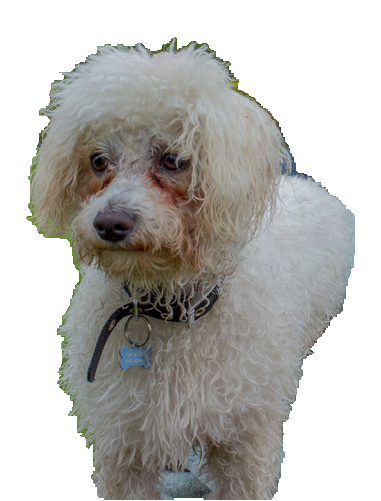

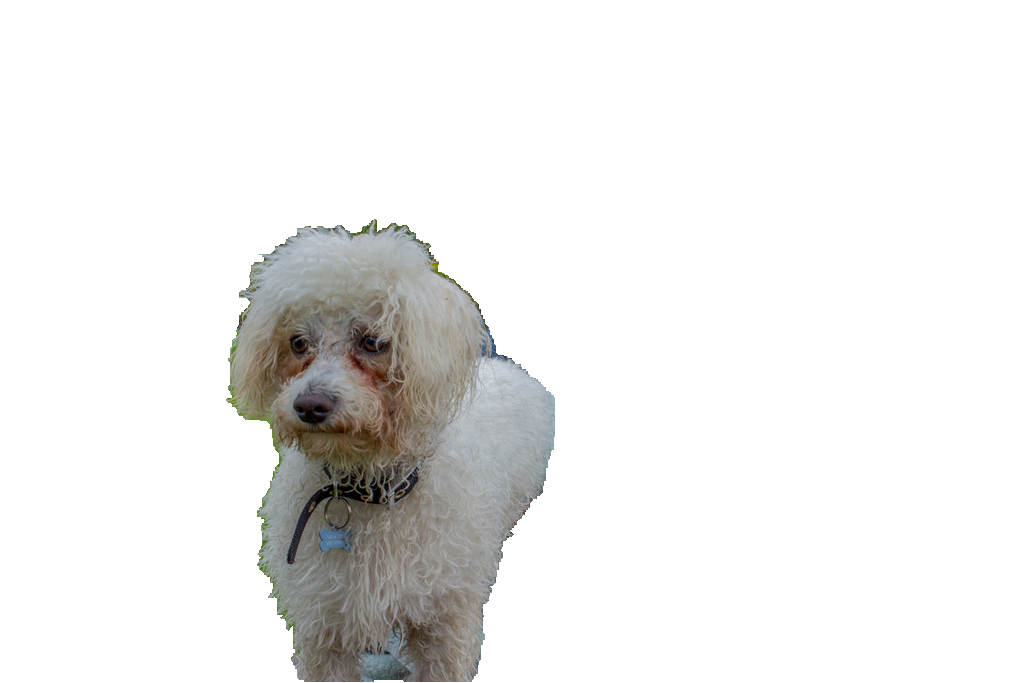

In [6]:
if subject_rows:
    sample = subject_rows[0]
    display(Image.open(REPO_ROOT / sample['crop_path']))
    if sample['isolated_path']:
        display(Image.open(REPO_ROOT / sample['isolated_path']))

## Step 5: Generate Line Diagrams

In [7]:
run_stage('generate_line_diagrams.py')

diagram_attempts_path = REPO_ROOT / 'outputs' / 'silver' / 'checkpoints' / 'line_diagram_attempts.ndjson'
diagram_attempt_rows = load_ndjson(diagram_attempts_path)
diagram_attempt_rows[:2]

Running: /home/shravan/Workspace/WildTrace/.venv/bin/python /home/shravan/Workspace/WildTrace/scripts/generate_line_diagrams.py --repo-root /home/shravan/Workspace/WildTrace --config-dir /home/shravan/Workspace/WildTrace/configs


/home/shravan/Workspace/WildTrace/.venv/lib/python3.12/site-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
100%|██████████| 4/4 [00:19<00:00,  4.80s/it]


[{'angle_bucket': 'left_profile',
  'category': 'Dog',
  'diagram_attempt': 1,
  'diagram_generator_backend': {'backend': 'flux_silhouette_rectifier',
   'prompt': 'simple clean line drawing of a dog, walking, facing left, left profile, coloring book page for children, full body visible, dog with distinct features matching the pose, black outline on white background, minimalist doodle, no shading, no fill, no color',
   'strength': 0.85},
  'diagram_path': 'outputs/silver/line_diagrams/Dog/053f21d0244601a8_attempt01.png',
  'lineage': {'generated_at': '2026-04-06T21:27:34.678554+00:00',
   'outline_generation_config_hash': '46625cfcb6258c4c',
   'subject_input_hash': '823171016bbcb442',
   'subject_sample_id': '053f21d0244601a8'},
  'outline_params': {},
  'sample_id': '053f21d0244601a8',
  'subcategory': 'dog'},
 {'angle_bucket': 'left_profile',
  'category': 'Dog',
  'diagram_attempt': 1,
  'diagram_generator_backend': {'backend': 'flux_silhouette_rectifier',
   'prompt': 'simple cle

Dog / dog / left_profile


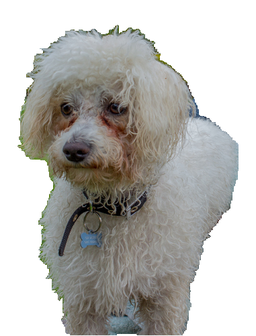

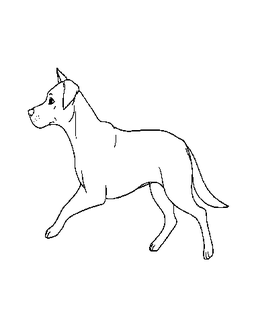


Dog / domestic_dog / left_profile


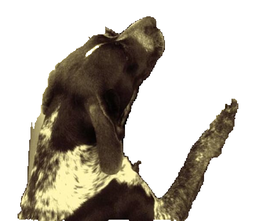

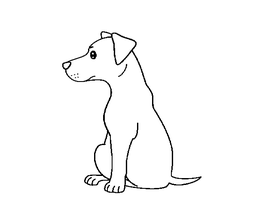


Cat / domestic_cat / left_profile


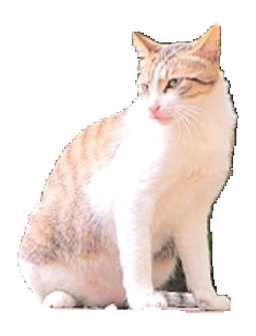

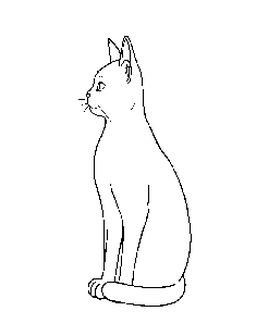


Cat / cat / front_right_3q


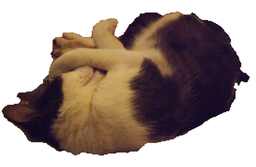

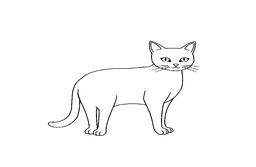


Horse / horse / left_profile


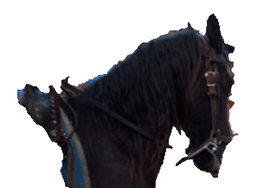

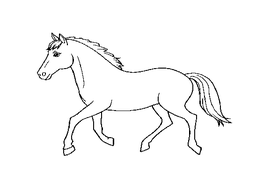


Dog / dog / left_profile


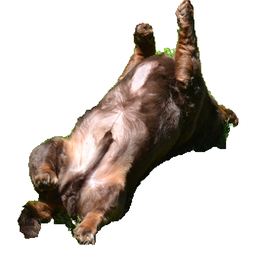

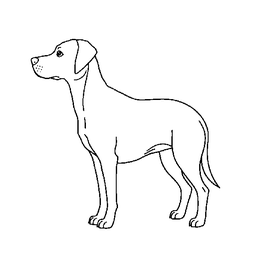

In [8]:
# Show crop and its generated line diagram side-by-side for the first few subjects.
# This is the primary visual check after any changes to outline_generator settings.
subjects_by_id = {r['sample_id']: r for r in load_ndjson(
    REPO_ROOT / 'outputs' / 'silver' / 'checkpoints' / 'silver_subjects.ndjson'
)}

for attempt in diagram_attempt_rows[:6]:
    sid = attempt['sample_id']
    subj = subjects_by_id.get(sid)
    diagram_path = REPO_ROOT / attempt['diagram_path']
    label = f"{attempt.get('category','?')} / {attempt.get('subcategory','?')} / {attempt.get('angle_bucket','?')}"
    print(label)
    if subj and subj.get('crop_path'):
        crop = Image.open(REPO_ROOT / subj['crop_path'])
        display(crop.resize((256, int(256 * crop.height / max(crop.width, 1))), Image.Resampling.LANCZOS))
    if diagram_path.exists():
        diag = Image.open(diagram_path)
        display(diag.resize((256, int(256 * diag.height / max(diag.width, 1))), Image.Resampling.LANCZOS))
    print()


## Step 6: Validate And Retry Diagrams

In [13]:
run_stage('validate_and_retry_diagrams.py')

validated_path = REPO_ROOT / 'outputs' / 'silver' / 'checkpoints' / 'validated_diagrams.ndjson'
validated_rows = load_ndjson(validated_path)
validated_rows[:2]

Running: /home/shravan/Workspace/WildTrace/.venv/bin/python /home/shravan/Workspace/WildTrace/scripts/validate_and_retry_diagrams.py --repo-root /home/shravan/Workspace/WildTrace --config-dir /home/shravan/Workspace/WildTrace/configs


/home/shravan/Workspace/WildTrace/.venv/lib/python3.12/site-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
100%|██████████| 4/4 [00:21<00:00,  5.49s/it]


[{'angle_bucket': 'left_profile',
  'category': 'Dog',
  'diagram_attempt': 2,
  'diagram_generator_backend': {'backend': 'flux_silhouette_rectifier',
   'prompt': 'simple clean line drawing of a dog, walking, facing left, left profile, coloring book page for children, full body visible, dog with distinct features matching the pose, black outline on white background, minimalist doodle, no shading, no fill, no color',
   'strength': 0.87},
  'diagram_path': 'outputs/silver/line_diagrams/Dog/053f21d0244601a8_attempt02.png',
  'diagram_validation_score': 0.6914,
  'diagram_validation_status': 'accepted',
  'lineage': {'diagram_attempt_count': 1,
   'subject_sample_id': '053f21d0244601a8'},
  'opencv_flags': [],
  'outline_validator_model': 'qwen2.5vl:7b',
  'outline_validator_reason': 'The image shows a simple cartoon doodle of an animal with a clear full-body outline and simple readable body parts. The drawing is done with black ink strokes on a mostly white background, and there is mini

## Step 7: Select Final By Angle

In [14]:
run_stage('select_final_by_angle.py')

selected_path = REPO_ROOT / 'outputs' / 'silver' / 'checkpoints' / 'selected_diagrams.ndjson'
selected_rows = load_ndjson(selected_path)
selected_rows[:2]

Running: /home/shravan/Workspace/WildTrace/.venv/bin/python /home/shravan/Workspace/WildTrace/scripts/select_final_by_angle.py --repo-root /home/shravan/Workspace/WildTrace --config-dir /home/shravan/Workspace/WildTrace/configs


[{'angle_bucket': 'left_profile',
  'category': 'Bird',
  'diagram_attempt': 1,
  'diagram_generator_backend': {'backend': 'flux_silhouette_rectifier',
   'prompt': 'simple clean line drawing of a bird, standing, front view, left profile, coloring book page for children, full body visible, bird with distinct features matching the pose, black outline on white background, minimalist doodle, no shading, no fill, no color',
   'strength': 0.85},
  'diagram_path': 'outputs/silver/line_diagrams/Bird/c3a528aafbfd7b55_attempt01.png',
  'diagram_validation_score': 0.6911,
  'diagram_validation_status': 'accepted',
  'lineage': {'diagram_attempt_count': 1,
   'initial_attempt_hash': 'd271894f9bfe68e4',
   'selection_source_hash': '71f7a5bf2d5ec547',
   'subject_sample_id': 'c3a528aafbfd7b55',
   'validation_config_hash': '541af83cd87489e0'},
  'opencv_flags': [],
  'outline_validator_model': 'qwen2.5vl:7b',
  'outline_validator_reason': 'The image shows a simple cartoon doodle of a bird with a c

## Step 8: Extract Trajectories & Export Gold

Running: /home/shravan/Workspace/WildTrace/.venv/bin/python /home/shravan/Workspace/WildTrace/scripts/extract_trajectories.py --repo-root /home/shravan/Workspace/WildTrace --config-dir /home/shravan/Workspace/WildTrace/configs
Running: /home/shravan/Workspace/WildTrace/.venv/bin/python /home/shravan/Workspace/WildTrace/scripts/export_gold_ndjson.py --repo-root /home/shravan/Workspace/WildTrace --config-dir /home/shravan/Workspace/WildTrace/configs
gold records: 9


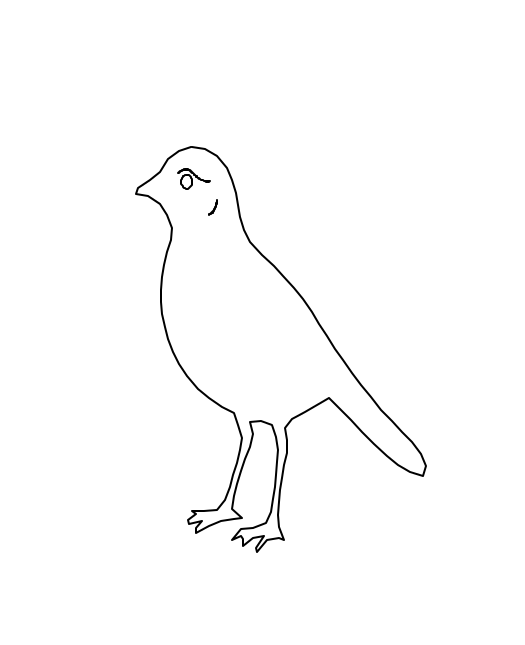

In [15]:
run_stage('extract_trajectories.py')

run_stage('export_gold_ndjson.py')

gold_path = REPO_ROOT / 'outputs' / 'gold' / 'records' / 'gold_samples.ndjson'
gold_rows = load_ndjson(gold_path)
print(f'gold records: {len(gold_rows)}')
if gold_rows:
    first = gold_rows[0]
    display(SVG(filename=str(REPO_ROOT / first['gold_refs']['svg_path'])))
    first['trajectory']


## Step 9: Generate Dataset Report

In [16]:
run_stage('generate_dataset_report.py')

report_json = REPO_ROOT / 'outputs' / 'reports' / 'dataset_report.json'
report_md = REPO_ROOT / 'outputs' / 'reports' / 'dataset_report.md'
print(report_json.read_text(encoding='utf-8'))
print('\n---\n')
print(report_md.read_text(encoding='utf-8'))

Running: /home/shravan/Workspace/WildTrace/.venv/bin/python /home/shravan/Workspace/WildTrace/scripts/generate_dataset_report.py --repo-root /home/shravan/Workspace/WildTrace --config-dir /home/shravan/Workspace/WildTrace/configs
{
  "accepted_diagrams": 12,
  "angles": {
    "Bird::bird": {
      "left_profile": 1
    },
    "Cat::cat": {
      "front_right_3q": 1
    },
    "Cat::domestic_cat": {
      "left_profile": 1
    },
    "Dog::dog": {
      "left_profile": 1
    },
    "Dog::domestic_dog": {
      "left_profile": 1,
      "right_profile": 1
    },
    "Fish::fish": {
      "front_left_3q": 1
    },
    "Horse::horse": {
      "left_profile": 1,
      "right_profile": 1
    }
  },
  "bronze_accepted": 15,
  "bronze_curated": 50,
  "categories": {
    "Bird": {
      "selected": 1
    },
    "Cat": {
      "selected": 2
    },
    "Dog": {
      "selected": 3
    },
    "Fish": {
      "selected": 1
    },
    "Horse": {
      "selected": 2
    }
  },
  "generated_at": "2026-